In [1]:
using WaveSpec.ContinuousSpectrums
using Plots

Precompiling packages...
   1879.3 ms  ✓ WaveSpec
  1 dependency successfully precompiled in 4 seconds. 209 already precompiled.
[ Info: WaveSpec initialized: Ready for spectral sea state synthesis.


In [2]:
# 1. Setup Parameters
Hs = 2.0
Tp = 8.0
h_shallow = 5.0   # Shallow water (depth < wavelength)
h_deep = 500.0    # Deep water (depth >> wavelength)

spec_shallow = TMA(Hs, Tp, h_shallow)
spec_deep = TMA(Hs, Tp, h_deep)

TMA{Float64}(JONSWAP{Float64}(2.0, 8.0, 0.125, 1.0, 1.0000078065322076, 0.7853981633974483, 0.07, 0.09), 500.0, 0.9999505217629222)

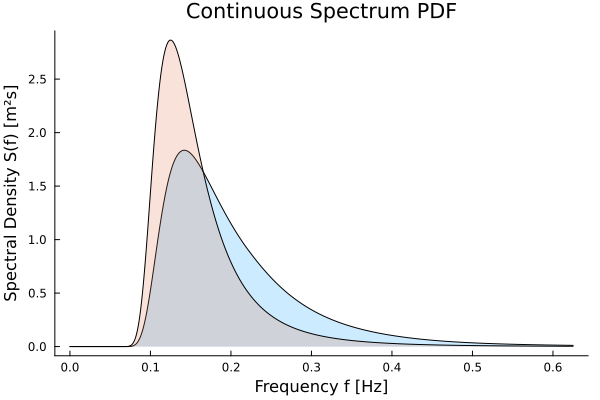

In [3]:
plot(spec_shallow, label="TMA")
plot!(spec_shallow.js, label="JONSWAP")

In [4]:
integrate(spec_shallow) |> println
integrate(spec_shallow.js) |> println

println((spec_shallow.js.Hs / 4.0)^2) 

0.24818380230165166
0.2495024474005799
0.25


In [5]:
spec_shallow.Ag_tma |> println
spec_shallow.js.Ag |> println

3.6242092766032132
1.0000078065322076


In [6]:
f_high = 2.0 * (1.0 / Tp)
        
# We check the raw impact of Phi
phi_shallow = get_phi(spec_shallow, f_high) 
phi_deep = get_phi(spec_deep, f_high)

println("Phi Shallow: $phi_shallow")
println("Phi Deep: $phi_deep")

Phi Shallow: 0.6142215579913588
Phi Deep: 1.0


In [7]:
# 1. Setup Parameters
Hs = 2.0
Tp = 6.0
U10 = 15.0 # Strong wind
spec = Donelan(Hs, Tp, U10)

Donelan{Float64}(2.0, 6.0, 15.0, 0.16666666666666666, 2.9267052179012243, 1.729137112921752, 0.08, 0.1)

In [8]:
using Test

# This is the most critical test for Donelan.
# At high frequencies, S(f) ∝ f⁻⁴
f1 = 10.0 * spec.fp
f2 = 11.0 * spec.fp

s1 = get_density(spec, f1)
s2 = get_density(spec, f2)

# Ratio should be (f2/f1)⁻⁴ = 2⁻⁴ = 1/16
# Note: We test rtol=1e-2 because the exp(-fr⁻²) term is small but not zero
@test s2 / s1 ≈ (f2 / f1)^-4 rtol=1e-2

Test Passed

In [9]:
using WaveSpec.PhysicalConstants: g

fp = 1.0 / Tp
cp = g / (2π * fp)
U_cp = U10 / cp

# If U_cp > 1, γ should be > 1.7
if U_cp > 1.0
    @test spec.γ > 1.7
else
    @test spec.γ == 1.7
end

# Test limits: check if γ stays within the 1.7 - 7.0 bounds
spec_slow = Donelan(Hs, Tp, 5.0)  # Very low wind
spec_fast = Donelan(Hs, Tp, 50.0) # Hurricane force
@test spec_slow.γ >= 1.7
@test spec_fast.γ <= 7.0

Test Passed

In [10]:
println(spec_fast.γ)

6.06397768958325


1.0


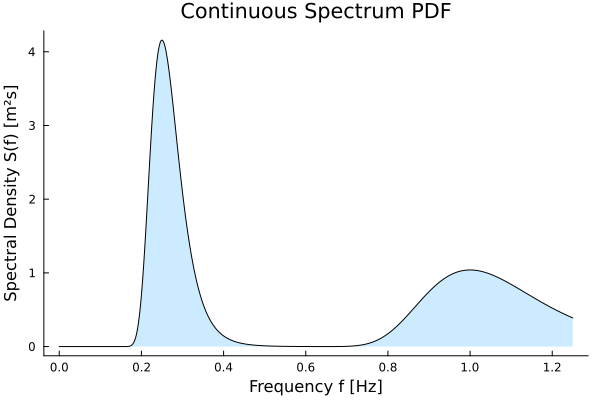

In [13]:
Hs1, Tp1, λ1 = 2.5, 1.0, 3.0
Hs2, Tp2, λ2 = 2.5, 4.0, 3.0

spec = OchiHubble(Hs1, Tp1, λ1, Hs2, Tp2, λ2)

println(spec.fp1)

plot(spec)

In [14]:
# Verify that the density is significant at both peak frequencies
f_swell = 1.0 / Tp1
f_wind  = 1.0 / Tp2

@test get_density(spec, f_swell) > 0.1
@test get_density(spec, f_wind) > 0.1

# Verify that a frequency between the peaks has lower density 
# (assuming peaks are sufficiently separated)
f_mid = (f_swell + f_wind) / 2.0
@test get_density(spec, f_mid) < get_density(spec, f_wind)

Test Passed

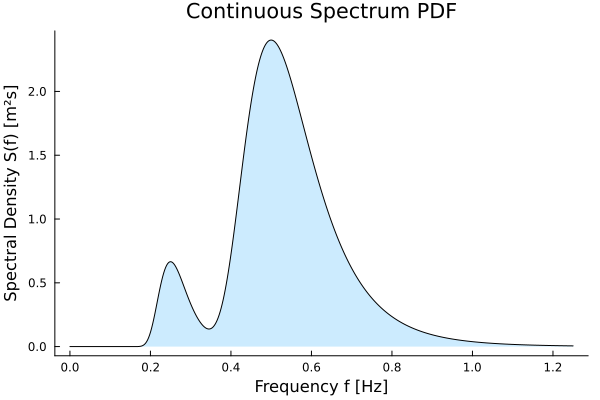

In [19]:
Hs_target = 3.0
Tp_target = 2.0

Hs_target_2 = 1.0
Tp_target_2 = 4.0
λ1 = 2
λ2 = 3

spec = OchiHubble(Hs_target, Tp_target, λ1, Hs_target_2, Tp_target_2, λ2)

plot(spec)